# Import the important lips

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.optimize import minimize
import random

# Read the data

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Ecommerce_Sales_Prediction_Dataset 1.csv")
df

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01/01/2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02/01/2023,Toys,569.48,3.60,Premium,6807.56,16
2,03/01/2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04/01/2023,Toys,923.27,0.61,Premium,9422.75,29
4,05/01/2023,Toys,710.17,47.83,Premium,1756.83,17
...,...,...,...,...,...,...,...
995,22/09/2025,Fashion,740.06,49.06,Regular,1890.83,34
996,23/09/2025,Electronics,517.10,28.48,Premium,8011.66,21
997,24/09/2025,Electronics,683.43,12.98,Occasional,3408.51,19
998,25/09/2025,Sports,51.26,21.85,Occasional,7335.62,26


# 1.1 **Descriptive** **Statistics**

# Measures of Frequency

In [4]:
categorical_cols = [col for col in df.select_dtypes(include='object').columns if col != 'Date']
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("Percentage distribution:")
    print(df[col].value_counts(normalize=True) * 100)


Column: Product_Category
Product_Category
Electronics    210
Sports         206
Toys           204
Home Decor     190
Fashion        190
Name: count, dtype: int64
Percentage distribution:
Product_Category
Electronics    21.0
Sports         20.6
Toys           20.4
Home Decor     19.0
Fashion        19.0
Name: proportion, dtype: float64

Column: Customer_Segment
Customer_Segment
Regular       345
Occasional    339
Premium       316
Name: count, dtype: int64
Percentage distribution:
Customer_Segment
Regular       34.5
Occasional    33.9
Premium       31.6
Name: proportion, dtype: float64


# Measures of Central Tendency

In [5]:
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode(numeric_only=True).iloc[0])

Mean:
 Price               505.24192
Discount             24.91975
Marketing_Spend    4912.83024
Units_Sold           29.63100
dtype: float64

Median:
 Price               509.310
Discount             24.965
Marketing_Spend    4837.245
Units_Sold           30.000
dtype: float64

Mode:
 Price              113.07
Discount            23.20
Marketing_Spend    100.30
Units_Sold          31.00
Name: 0, dtype: float64


# Measures of Dispersion

In [6]:
range_ = df.max(numeric_only=True) - df.min(numeric_only=True)
print("Range:\n", range_)
print("\nVariance:\n", df.var(numeric_only=True))
print("\nStandard Deviation:\n", df.std(numeric_only=True))

Range:
 Price               984.83
Discount             49.91
Marketing_Spend    9895.32
Units_Sold           52.00
dtype: float64

Variance:
 Price              8.397897e+04
Discount           2.085122e+02
Marketing_Spend    8.069023e+06
Units_Sold         5.282366e+01
dtype: float64

Standard Deviation:
 Price               289.791248
Discount             14.439951
Marketing_Spend    2840.602656
Units_Sold            7.267989
dtype: float64


# Measures of Position

In [7]:
print(df.quantile([0.25, 0.5, 0.75], numeric_only=True))

         Price  Discount  Marketing_Spend  Units_Sold
0.25  243.3425   12.9950         2413.020        24.0
0.50  509.3100   24.9650         4837.245        30.0
0.75  747.5925   37.5625         7319.675        34.0


# Outlier Detection

In [8]:
z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
outliers = (z_scores > 3).sum(axis=0)
print("Number of Outliers per Numeric Column:\n", outliers)

Number of Outliers per Numeric Column:
 [0 0 0 3]


# 1.2 **Relationships Between Features**

# Contingency Table

In [9]:
contingency = pd.crosstab(df['Product_Category'], df['Customer_Segment'])
print("\n--- Contingency Table: Product Category vs Customer Segment ---")
print(contingency)


--- Contingency Table: Product Category vs Customer Segment ---
Customer_Segment  Occasional  Premium  Regular
Product_Category                              
Electronics               66       62       82
Fashion                   67       60       63
Home Decor                69       59       62
Sports                    62       68       76
Toys                      75       67       62


# **Visualization**

#Histogram of Units Sold

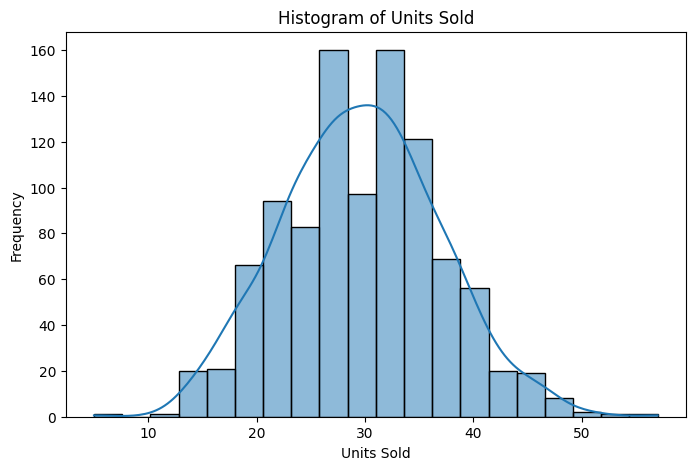

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Units_Sold'], bins=20, kde=True)
plt.title("Histogram of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

#Box Plot of Units Sold by Product Category

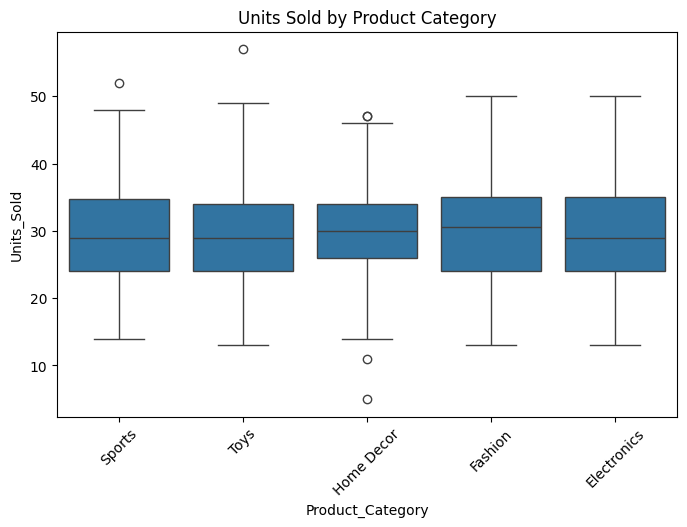

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Product_Category', y='Units_Sold', data=df)
plt.title("Units Sold by Product Category")
plt.xticks(rotation=45)
plt.show()

#Violin Plot of Units Sold by Customer Segment

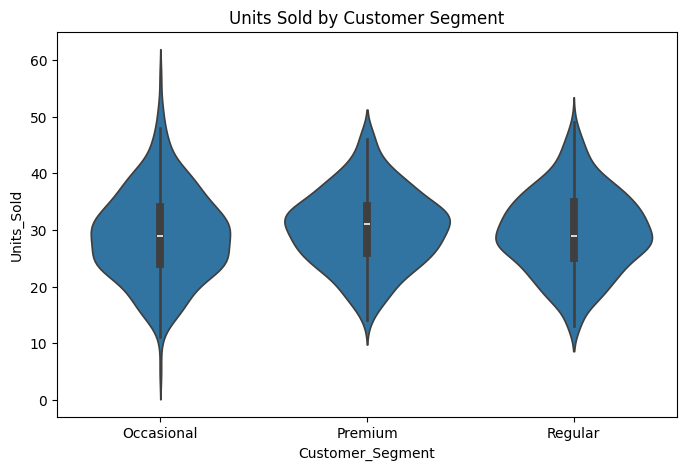

In [12]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Customer_Segment', y='Units_Sold', data=df)
plt.title("Units Sold by Customer Segment")
plt.show()

#Scatter Plot - Price vs Units Sold

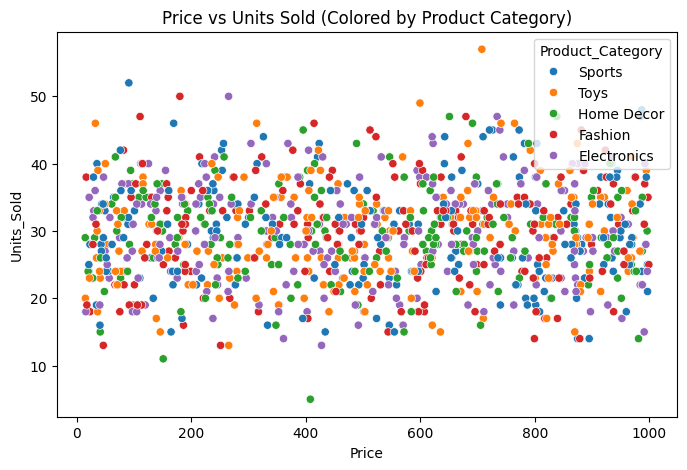

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Price', y='Units_Sold', hue='Product_Category', data=df)
plt.title("Price vs Units Sold (Colored by Product Category)")
plt.show()

#pie chart Product_Category and sum Units_Sold

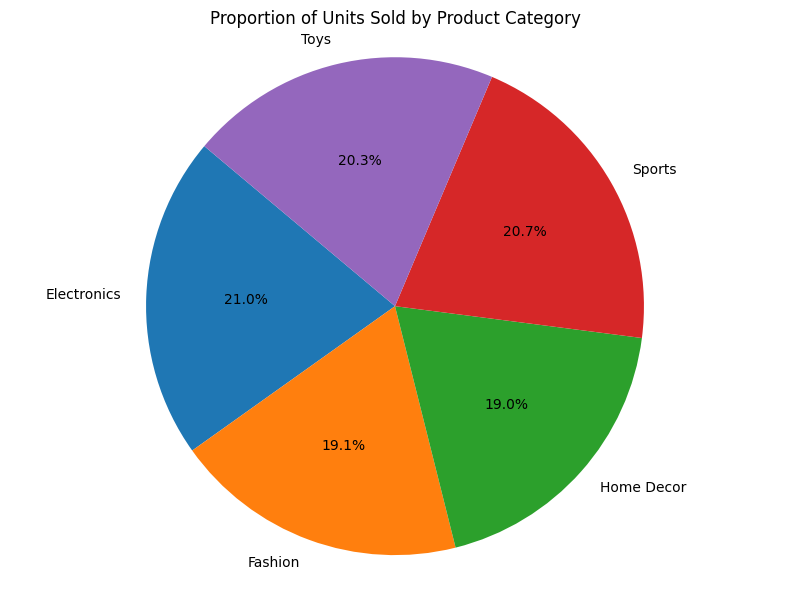

In [15]:
category_sales = df.groupby('Product_Category')['Units_Sold'].sum()

plt.figure(figsize=(8, 6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Units Sold by Product Category')
plt.axis('equal')
plt.tight_layout()
plt.show()

#Correlation Heatmap

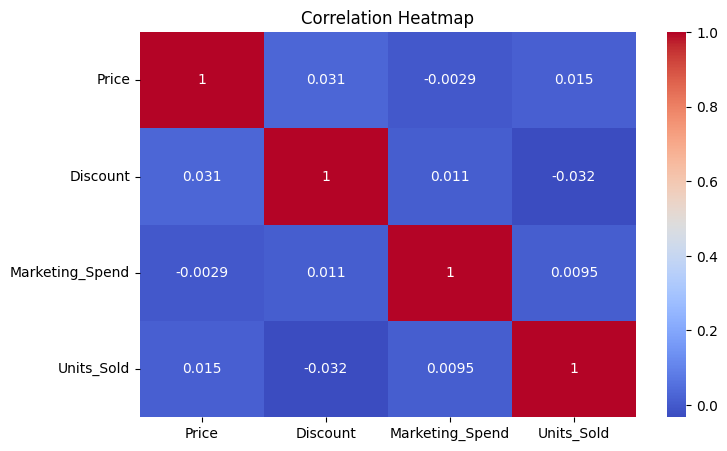

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **predictive analytics**

# Drop non-numeric and irrelevant columns for modeling

In [21]:
df_clean = df.drop(columns=['Date'])

# One-hot encode categorical features

In [22]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Define features and target

In [17]:
X = df_encoded.drop(columns=['Units_Sold'])
y = df_encoded['Units_Sold']

# Feature Selection Techniques

#1: SelectKBest

In [18]:
selector_kbest = SelectKBest(score_func=f_regression, k='all')
selector_kbest.fit(X, y)
scores_kbest = pd.Series(selector_kbest.scores_, index=X.columns).sort_values(ascending=False)

#2: Random Forest Feature Importances

In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
scores_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Combine results for comparison

In [20]:
feature_scores_df = pd.DataFrame({
    'SelectKBest (F-score)': scores_kbest,
    'RandomForest Importance': scores_rf
})
print("Feature Selection Comparison:\n")
print(feature_scores_df)


Feature Selection Comparison:

                             SelectKBest (F-score)  RandomForest Importance
Customer_Segment_Premium                  3.640384                 0.024248
Customer_Segment_Regular                  0.000040                 0.025380
Discount                                  1.054854                 0.266445
Marketing_Spend                           0.089558                 0.299449
Price                                     0.226024                 0.291770
Product_Category_Fashion                  0.049699                 0.023925
Product_Category_Home Decor               0.021121                 0.018207
Product_Category_Sports                   0.051061                 0.026564
Product_Category_Toys                     0.202793                 0.024012


# Split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#1: Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

#2: Decision Tree Regressor

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)
tree_mae = mean_absolute_error(y_test, tree_preds)
tree_r2 = r2_score(y_test, tree_preds)

#3: Exponential Smoothing (Time Series)

In [ ]:
df_time = df.sort_values('Date')
ts_model = ExponentialSmoothing(df_time['Units_Sold'], trend='add', seasonal=None, initialization_method="estimated")
ts_fit = ts_model.fit()
ts_preds = ts_fit.forecast(steps=200)
ts_actual = df_time['Units_Sold'][-200:]
ts_mae = mean_absolute_error(ts_actual, ts_preds)
ts_r2 = r2_score(ts_actual, ts_preds)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Compile results

In [ ]:
forecast_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Exponential Smoothing'],
    'MAE': [lr_mae, tree_mae, ts_mae],
    'R2 Score': [lr_r2, tree_r2, ts_r2]
})
forecast_results

,Model,MAE,R2 Score
0,Linear Regression,5.960061,-0.035296
1,Decision Tree,8.440000,-1.049598
2,Exponential Smoothing,5.594672,-0.001442


# Visualizations

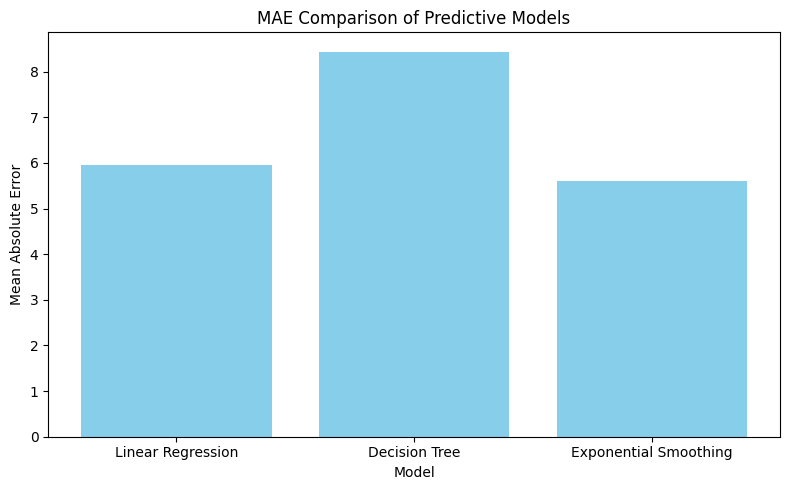

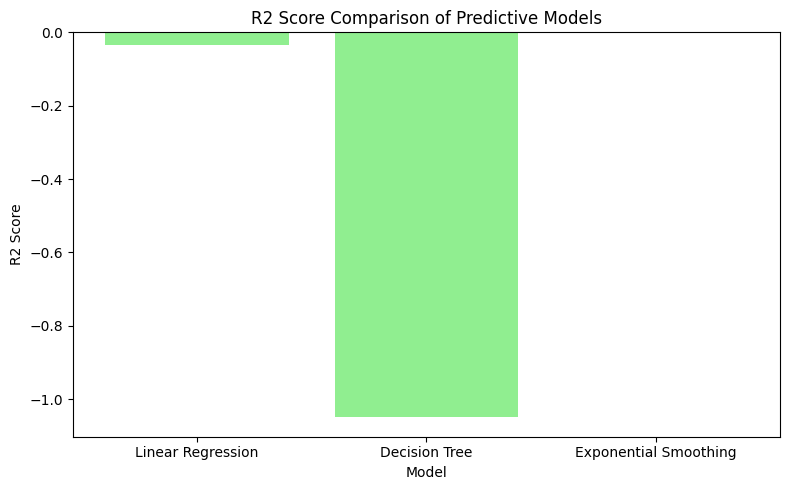

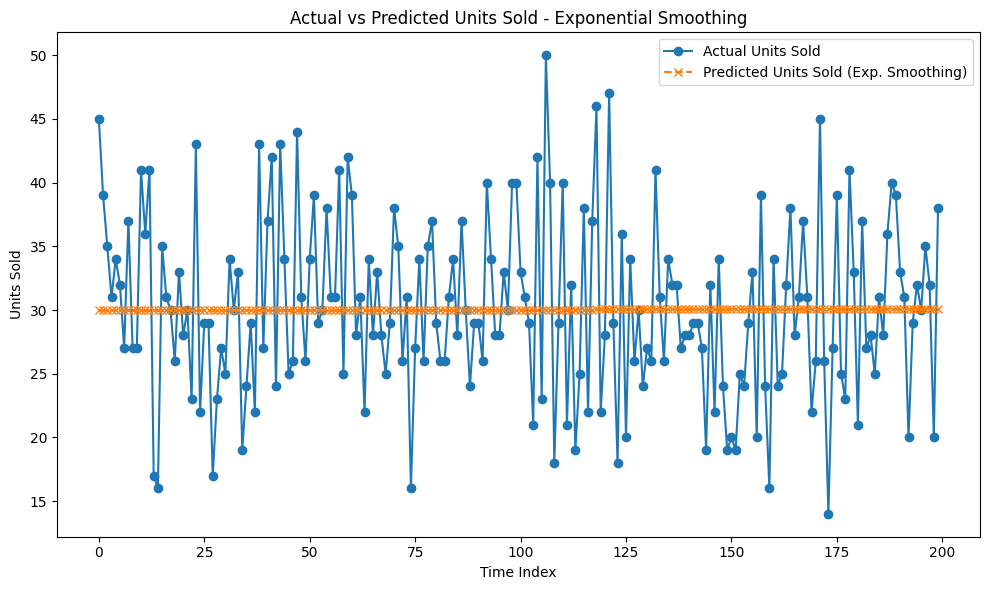

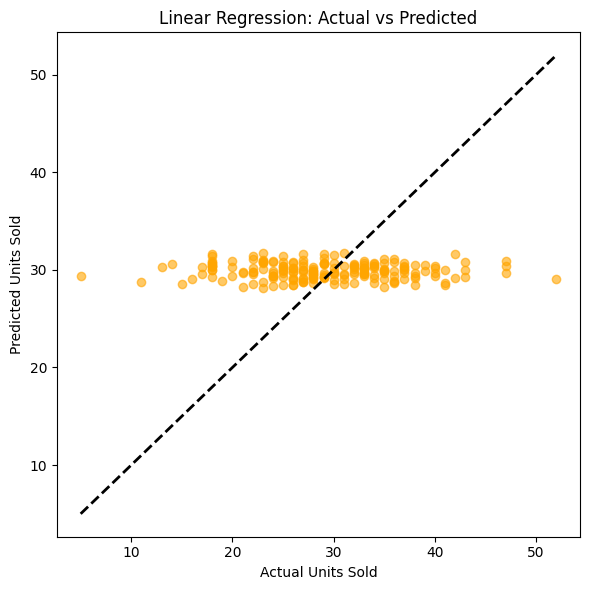

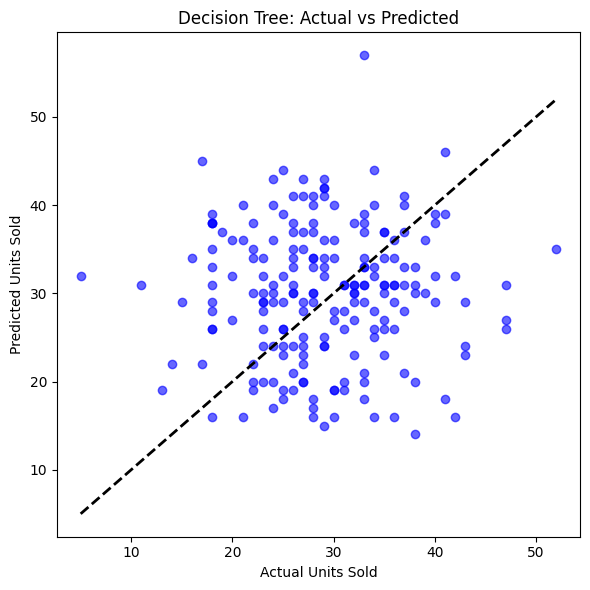

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(forecast_results['Model'], forecast_results['MAE'], color='skyblue')
plt.title('MAE Comparison of Predictive Models')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(forecast_results['Model'], forecast_results['R2 Score'], color='lightgreen')
plt.title('R2 Score Comparison of Predictive Models')
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(ts_actual.values, label='Actual Units Sold', marker='o')
plt.plot(ts_preds.values, label='Predicted Units Sold (Exp. Smoothing)', linestyle='--', marker='x')
plt.title('Actual vs Predicted Units Sold - Exponential Smoothing')
plt.xlabel('Time Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr_preds, color='orange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(y_test, tree_preds, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Decision Tree: Actual vs Predicted')
plt.tight_layout()
plt.show()


#Findings

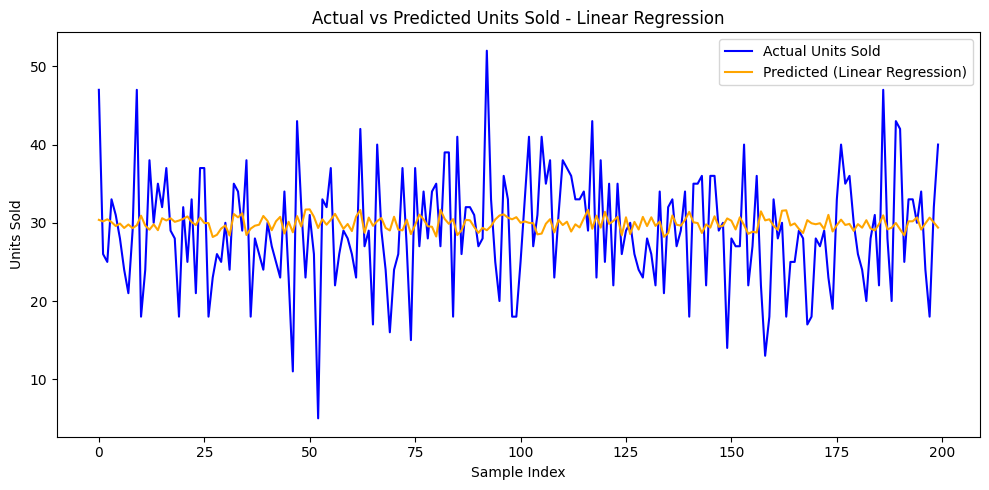

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test.values, label='Actual Units Sold', color='blue')
plt.plot(range(len(lr_preds)), lr_preds, label='Predicted (Linear Regression)', color='orange')
plt.title('Actual vs Predicted Units Sold - Linear Regression')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

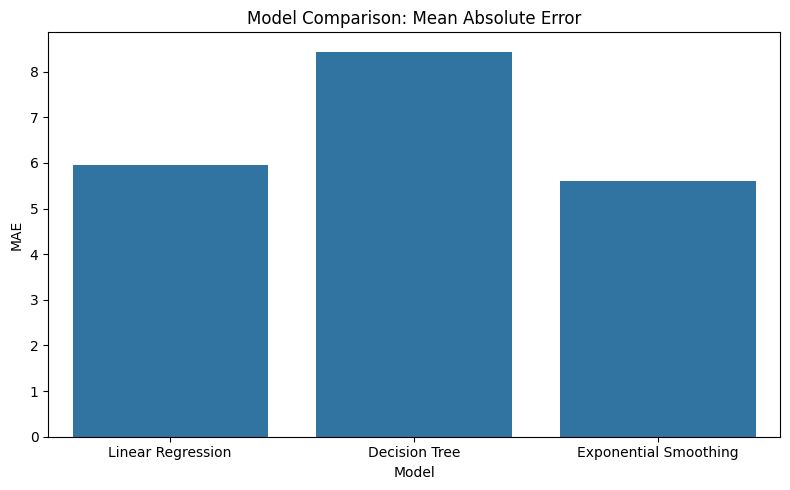

In [ ]:
model_names = ['Linear Regression', 'Decision Tree', 'Exponential Smoothing']
mae_values = [lr_mae, tree_mae, ts_mae]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=mae_values)
plt.title('Model Comparison: Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Model')
plt.tight_layout()
plt.show()


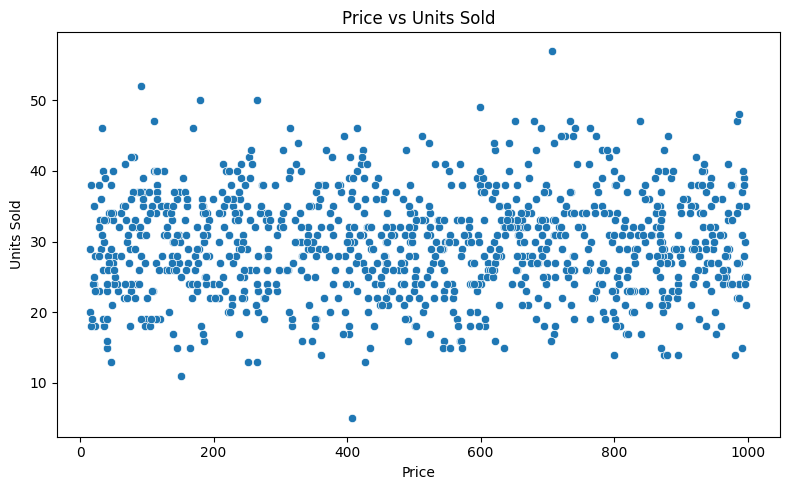

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_encoded['Price'], y=df_encoded['Units_Sold'])
plt.title('Price vs Units Sold')
plt.xlabel('Price')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

#Linear Programming

In [ ]:
X = -df[['Price', 'Discount', 'Marketing_Spend']].values
y = df['Units_Sold'].values
x0 = [1, 1, 1, 1]
bounds = [(-5, 0)] * 4
result = minimize(
    lambda w: np.mean((y - (w[0] + w[1]*X[:, 0] + w[2]*X[:, 1] + w[3]*X[:, 2])) ** 2),
    x0=x0,
    bounds=bounds
)


In [ ]:
optimal_weights = result.x
final_mse = result.fun
print("Optimal Weights:")
print("W1 (Bias) =", round(optimal_weights[0], 4))
print("W2 (Price) =", round(optimal_weights[1], 4))
print("W3 (Discount) =", round(optimal_weights[2], 4))
print("W4 (Marketing Spend) =", round(optimal_weights[3], 4))
print("Final MSE =", round(final_mse, 4))

Optimal Weights:
W1 (Bias) = 0.0
W2 (Price) = 0.0
W3 (Discount) = 0.0
W4 (Marketing Spend) = 0.0
Final MSE = 930.767


In [ ]:
preds = optimal_weights[0] + optimal_weights[1]*X[:, 0] + optimal_weights[2]*X[:, 1] + optimal_weights[3]*X[:, 2]

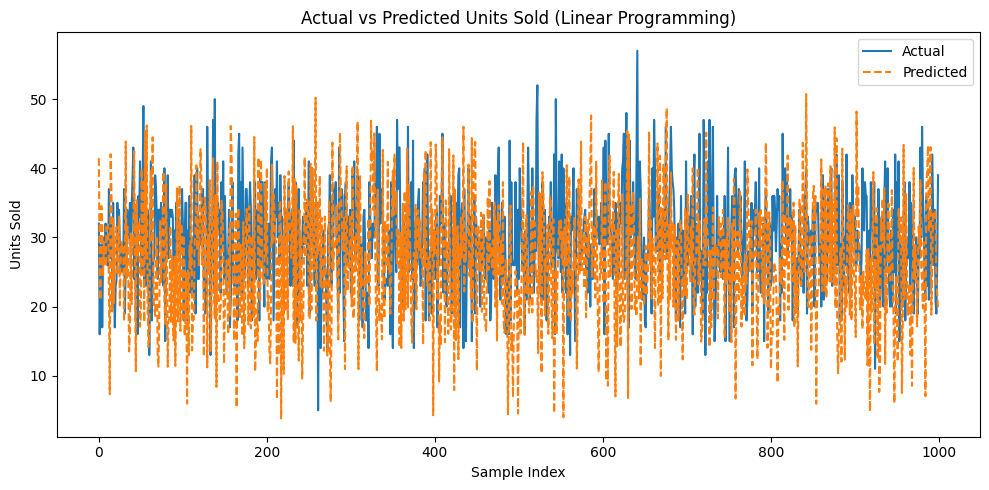

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y, label='Actual')
plt.plot(preds, label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Units Sold (Linear Programming)')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

#Genetic Algorithm

In [ ]:
population_size = 30
iterations = 5
runs = 10
best_weights_per_run = []
mse_per_run = []
convergence_data = []

In [ ]:
for run in range(runs):
    population = [np.random.uniform(0, 5, 4) for _ in range(population_size)]
    best_mse_per_iter = []

    for i in range(iterations):
        scores = [np.mean((y - (w[0] + w[1]*X[:,0] + w[2]*X[:,1] + w[3]*X[:,2]))**2) for w in population]
        population = [x for _, x in sorted(zip(scores, population))][:10]
        best_mse_per_iter.append(min(scores))

        while len(population) < population_size:
            p1, p2 = random.sample(population, 2)
            child = (np.array(p1) + np.array(p2)) / 2
            mutation = np.random.normal(0, 0.1, 4)
            child += mutation
            child = np.clip(child, 0, 5)
            population.append(child)

    best_weights = population[0]
    best_mse = np.mean((y - (best_weights[0] + best_weights[1]*X[:,0] + best_weights[2]*X[:,1] + best_weights[3]*X[:,2]))**2)
    best_weights_per_run.append(best_weights)
    mse_per_run.append(best_mse)
    convergence_data.append(best_mse_per_iter)


In [ ]:
best_index = np.argmin(mse_per_run)
best_weights = best_weights_per_run[best_index]
preds = best_weights[0] + best_weights[1]*X[:,0] + best_weights[2]*X[:,1] + best_weights[3]*X[:,2]


In [ ]:
print("Best Weights from GA:")
print("W1 =", round(best_weights[0], 4))
print("W2 =", round(best_weights[1], 4))
print("W3 =", round(best_weights[2], 4))
print("W4 =", round(best_weights[3], 4))
print("Best MSE =", round(mse_per_run[best_index], 4))

Best Weights from GA:
W1 = 3.4332
W2 = 0.1551
W3 = 2.9197
W4 = 0.0463
Best MSE = 145309.7475


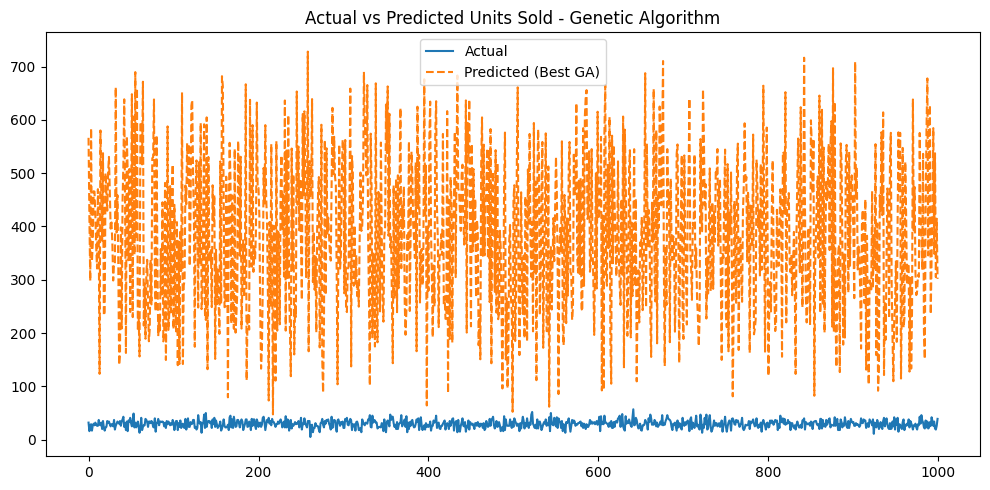

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y, label='Actual')
plt.plot(preds, label='Predicted (Best GA)', linestyle='--')
plt.title('Actual vs Predicted Units Sold - Genetic Algorithm')
plt.legend()
plt.tight_layout()
plt.show()

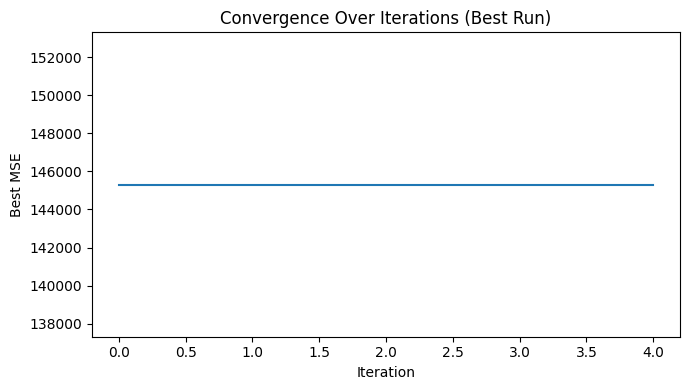

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(convergence_data[best_index])
plt.title('Convergence Over Iterations (Best Run)')
plt.xlabel('Iteration')
plt.ylabel('Best MSE')
plt.tight_layout()
plt.show()

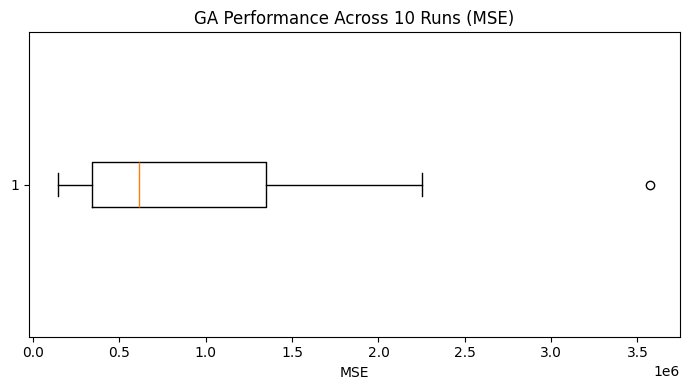

In [ ]:
plt.figure(figsize=(7, 4))
plt.boxplot(mse_per_run, vert=False)
plt.title('GA Performance Across 10 Runs (MSE)')
plt.xlabel('MSE')
plt.tight_layout()
plt.show()